# Population Dynamics

## Real-World Scenario: Modeling Cell Growth in a Bioreactor

In whole cell modeling and bioprocess engineering, predicting how a cell population grows over time is fundamental. Will the culture grow exponentially forever? When does nutrient limitation kick in? What is the maximum population the bioreactor can sustain?

Section 1.5 of AEM gives us the mathematical tools to answer these questions:

- **Linear first-order ODEs** and their general solution via integrating factors
- The **Bernoulli equation** — a nonlinear ODE reducible to linear form
- The **logistic equation** (Verhulst model) — a Bernoulli equation modeling bounded growth
- **Population dynamics**: Malthus's law, carrying capacity, equilibrium solutions, and stability

We'll model *E. coli* growth in a bioreactor, comparing unbounded exponential growth (Malthus) with the more realistic logistic model that accounts for nutrient depletion and waste accumulation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.integrate import solve_ivp

plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'

## 1. Linear First-Order ODEs — General Solution

A first-order ODE is **linear** if it can be written as:

$$y' + p(x)\,y = r(x)$$

The key idea is to multiply both sides by an **integrating factor** $e^h$ where $h = \int p(x)\,dx$, which turns the left side into an exact derivative $(e^h y)'$. This yields the **general solution formula**:

$$\boxed{y(x) = e^{-h}\!\left(\int e^h\, r\, dx + c\right), \qquad h = \int p(x)\,dx}$$

The solution is a sum of two responses:
- **Response to initial data**: $c\,e^{-h}$ (the homogeneous solution)
- **Response to input $r$**: $e^{-h}\!\int e^h r\,dx$ (the particular solution)

### Biotech example: Nutrient-Limited Protein Production

A bioreactor cell produces a protein at rate $r(t)$ while the protein degrades at rate proportional to its concentration. If $y(t)$ is the protein concentration:

$$y' + K\,y = r(t)$$

where $K$ is the degradation rate constant.

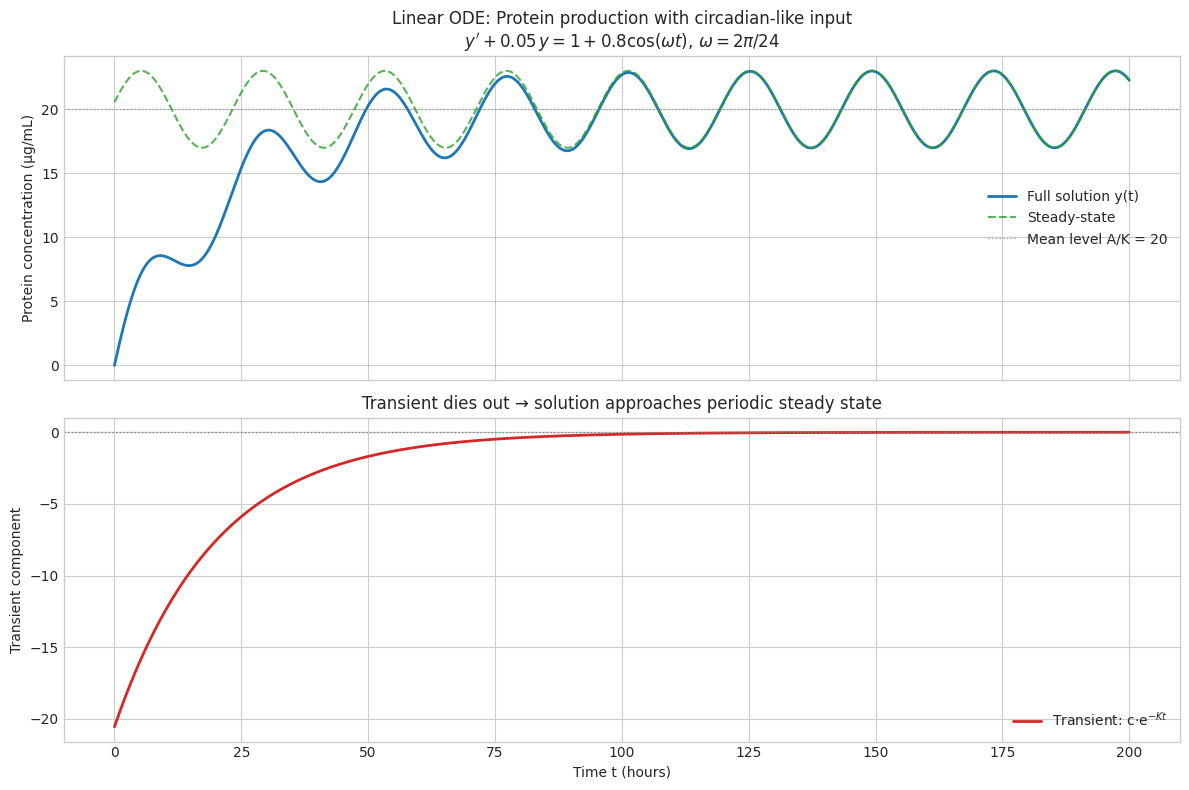

In [2]:
# Protein production with sinusoidal input (circadian-like rhythm)
# y' + Ky = A + B cos(ωt),  y(0) = 0
# This mirrors Example 3 from AEM 1.5 (hormone level model)

K = 0.05       # degradation rate (per hour)
A = 1.0        # baseline production rate (μg/mL/hr)
B = 0.8        # amplitude of oscillation
omega = 2 * np.pi / 24  # 24-hour cycle

# General solution (derived via integrating factor, h = Kt):
# y(t) = A/K + B/(K² + ω²) * (K cos(ωt) + ω sin(ωt)) + c·e^{-Kt}
# With y(0) = 0:  c = -A/K - BK/(K² + ω²)

c = -A / K - B * K / (K**2 + omega**2)

t = np.linspace(0, 200, 2000)
y_general = (A / K
             + B / (K**2 + omega**2) * (K * np.cos(omega * t) + omega * np.sin(omega * t))
             + c * np.exp(-K * t))

# Steady-state (transient term → 0)
y_steady = A / K + B / (K**2 + omega**2) * (K * np.cos(omega * t) + omega * np.sin(omega * t))

# Transient
y_transient = c * np.exp(-K * t)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax = axes[0]
ax.plot(t, y_general, 'C0', lw=2, label='Full solution y(t)')
ax.plot(t, y_steady, 'C2--', lw=1.5, alpha=0.8, label='Steady-state')
ax.axhline(A / K, color='gray', ls=':', lw=1, alpha=0.6, label=f'Mean level A/K = {A/K:.0f}')
ax.set_ylabel('Protein concentration (μg/mL)')
ax.set_title('Linear ODE: Protein production with circadian-like input\n'
             r"$y' + 0.05\,y = 1 + 0.8\cos(\omega t)$, $\omega = 2\pi/24$")
ax.legend(loc='right')

ax = axes[1]
ax.plot(t, y_transient, 'C3', lw=2, label=f'Transient: c·e$^{{-Kt}}$')
ax.axhline(0, color='gray', ls=':', lw=1)
ax.set_xlabel('Time t (hours)')
ax.set_ylabel('Transient component')
ax.set_title('Transient dies out → solution approaches periodic steady state')
ax.legend()

plt.tight_layout()
plt.show()

The solution has two parts (eq. 5 in AEM):

$$\text{Total Output} = \underbrace{e^{-h}\!\int e^h r\,dx}_{\text{Response to input } r} + \underbrace{c\,e^{-h}}_{\text{Response to initial data}}$$

The transient term $c\,e^{-Kt}$ decays to zero regardless of the initial condition. After enough time, only the **steady-state** response to the periodic input remains — the system "forgets" its initial state.

## 2. The Bernoulli Equation — Reduction to Linear Form

Many biological models are **nonlinear** but can be transformed into linear ODEs. The **Bernoulli equation** is:

$$y' + p(x)\,y = g(x)\,y^a \qquad (a \neq 0, 1)$$

**The trick:** substitute $u = y^{1-a}$, then differentiate:

$$u' = (1-a)\,y^{-a}\,y' = (1-a)\,y^{-a}\bigl(g\,y^a - p\,y\bigr) = (1-a)(g - p\,y^{1-a}) = (1-a)\,g - (1-a)\,p\,u$$

This gives the **linear ODE** in $u$:

$$\boxed{u' + (1-a)\,p\,u = (1-a)\,g}$$

which we solve using the formula from Section 1, then recover $y = u^{1/(1-a)}$.

## 3. The Logistic Equation (Verhulst Model)

The most important Bernoulli equation in biology is the **logistic equation**:

$$\boxed{y' = Ay - By^2}$$

This is a Bernoulli equation with $p = -A$, $g = -B$, and $a = 2$.

**Step-by-step derivation** (AEM Example 4):

1. Write in Bernoulli form: $y' - Ay = -By^2$ (so $a = 2$)
2. Set $u = y^{1-2} = y^{-1} = 1/y$
3. Differentiate: $u' = -y^{-2}y' = -y^{-2}(Ay - By^2) = B - Ay^{-1} = B - Au$
4. Linear ODE: $u' + Au = B$
5. General solution: $u = c\,e^{-At} + B/A$
6. Back-substitute $y = 1/u$:

$$\boxed{y(t) = \frac{1}{c\,e^{-At} + B/A} = \frac{A/B}{1 + (A/(B\,y_0) - 1)\,e^{-At}}}$$

where we used the initial condition $y(0) = y_0$ to find $c = 1/y_0 - B/A$.

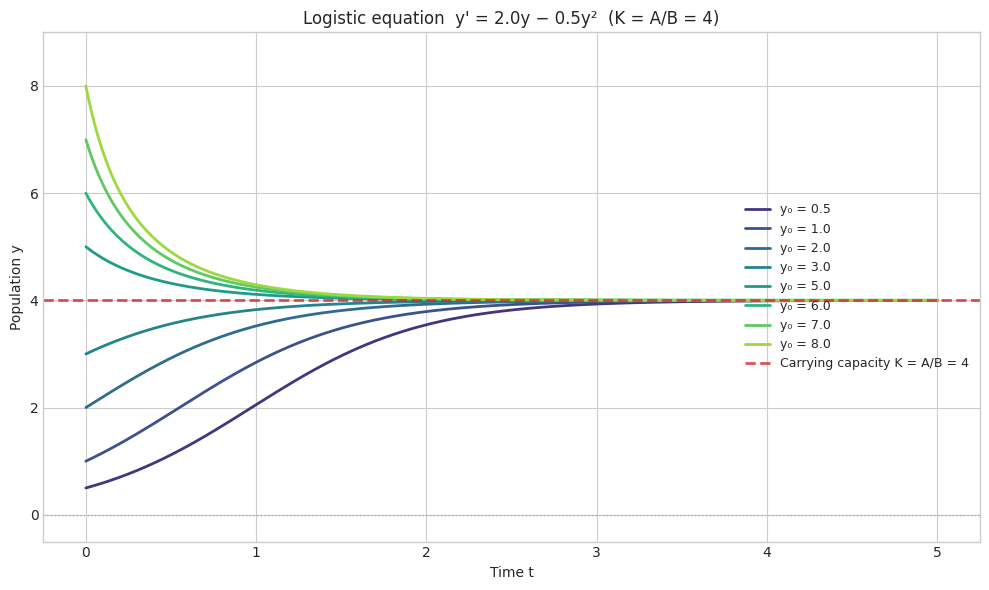

In [3]:
# Reproduce AEM Figure 21: Logistic equation solutions with A/B = 4
A_log = 2.0   # growth rate
B_log = 0.5   # braking coefficient  →  carrying capacity K = A/B = 4
K_capacity = A_log / B_log

def logistic_solution(t, y0, A, B):
    """Exact solution of y' = Ay - By², y(0) = y0."""
    if y0 == 0:
        return np.zeros_like(t)
    K = A / B
    return K / (1 + (K / y0 - 1) * np.exp(-A * t))

t = np.linspace(0, 5, 300)

fig, ax = plt.subplots(figsize=(10, 6))

# Solutions from different initial conditions (as in Fig. 21)
y0_values = [0.5, 1.0, 2.0, 3.0, 5.0, 6.0, 7.0, 8.0]
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(y0_values)))

for y0, col in zip(y0_values, colors):
    y = logistic_solution(t, y0, A_log, B_log)
    ax.plot(t, y, color=col, lw=2, label=f'y₀ = {y0}')

ax.axhline(K_capacity, color='C3', ls='--', lw=2, alpha=0.8,
           label=f'Carrying capacity K = A/B = {K_capacity:.0f}')
ax.axhline(0, color='gray', ls=':', lw=1, alpha=0.5)

ax.set_xlabel('Time t')
ax.set_ylabel('Population y')
ax.set_title(f'Logistic equation  y\' = {A_log}y − {B_log}y²  (K = A/B = {K_capacity:.0f})')
ax.legend(loc='right', fontsize=9)
ax.set_ylim(-0.5, 9)
plt.tight_layout()
plt.show()

Key observations from the logistic model:

- **Below carrying capacity** ($y_0 < K = A/B$): population grows with a characteristic S-shaped (sigmoidal) curve
- **Above carrying capacity** ($y_0 > K$): population decreases back toward $K$
- **All solutions converge to $K = A/B$**, regardless of initial condition (as long as $y_0 > 0$)
- The **braking term** $-By^2$ prevents unbounded growth: rewriting $y' = Ay(1 - (B/A)y)$, we see $y' > 0$ when $y < A/B$ and $y' < 0$ when $y > A/B$

## 4. Population Dynamics — Malthus vs. Logistic Growth

### Malthus's Law (Exponential Growth)

When $B = 0$, the logistic equation reduces to $y' = Ay$, giving **exponential growth**:

$$y(t) = y_0 \, e^{At}$$

This is **Malthus's law** — reasonable for small populations in abundant resources, but unrealistic long-term since it predicts infinite growth.

### The Logistic Model (Bounded Growth)

The logistic equation adds the braking term $-By^2$:

$$y' = Ay - By^2 = Ay\!\left(1 - \frac{y}{K}\right), \qquad K = \frac{A}{B}$$

Let's compare both models for *E. coli* growth in a bioreactor.

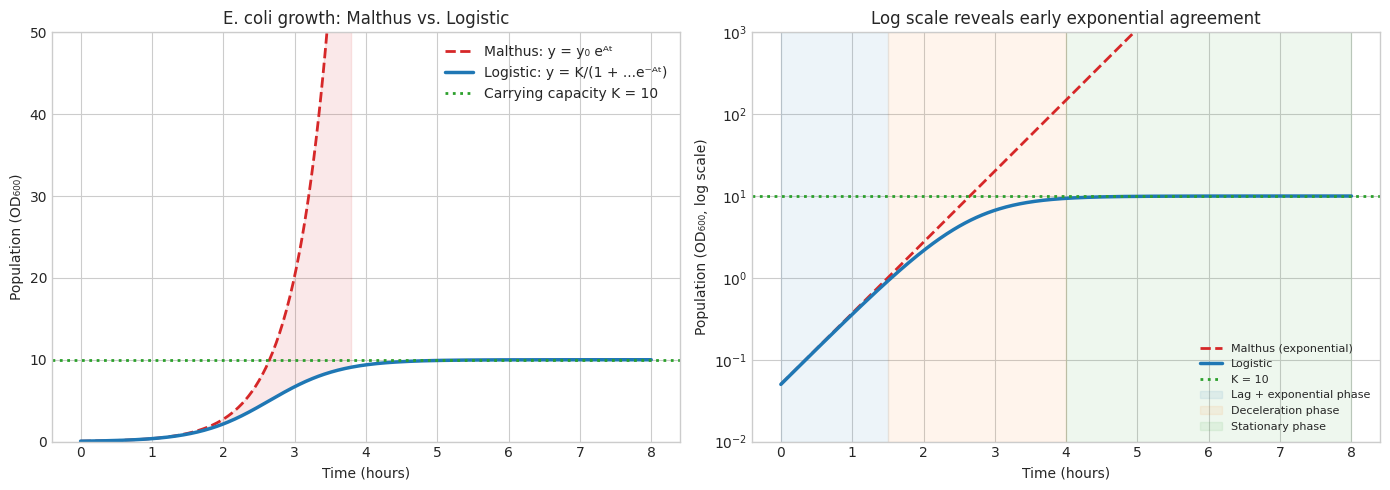

After 8 hours:
  Malthus predicts: OD = 444306 (unrealistic!)
  Logistic predicts: OD = 10.00 (bounded by K = 10)


In [4]:
# E. coli growth parameters (realistic values)
# Doubling time ~20 min → growth rate r ≈ ln(2)/20 ≈ 0.035 per min ≈ 2.08 per hour
A_ecoli = 2.0       # intrinsic growth rate (per hour)
B_ecoli = 0.2       # braking coefficient
K_ecoli = A_ecoli / B_ecoli  # carrying capacity = 10 (in OD₆₀₀ units)
y0_ecoli = 0.05     # initial OD₆₀₀ (dilute inoculum)

t_hours = np.linspace(0, 8, 500)

y_malthus = y0_ecoli * np.exp(A_ecoli * t_hours)
y_logistic = logistic_solution(t_hours, y0_ecoli, A_ecoli, B_ecoli)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: linear scale
ax = axes[0]
ax.plot(t_hours, y_malthus, 'C3', lw=2, ls='--', label='Malthus: y = y₀ eᴬᵗ')
ax.plot(t_hours, y_logistic, 'C0', lw=2.5, label='Logistic: y = K/(1 + ...e⁻ᴬᵗ)')
ax.axhline(K_ecoli, color='C2', ls=':', lw=2, label=f'Carrying capacity K = {K_ecoli:.0f}')
ax.fill_between(t_hours, y_logistic, y_malthus,
                where=y_malthus < 100, alpha=0.1, color='C3')
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Population (OD₆₀₀)')
ax.set_title('E. coli growth: Malthus vs. Logistic')
ax.set_ylim(0, 50)
ax.legend()

# Right: log scale — early growth is identical
ax = axes[1]
ax.semilogy(t_hours, y_malthus, 'C3', lw=2, ls='--', label='Malthus (exponential)')
ax.semilogy(t_hours, y_logistic, 'C0', lw=2.5, label='Logistic')
ax.axhline(K_ecoli, color='C2', ls=':', lw=2, label=f'K = {K_ecoli:.0f}')

# Mark the phases
ax.axvspan(0, 1.5, alpha=0.08, color='C0', label='Lag + exponential phase')
ax.axvspan(1.5, 4.0, alpha=0.08, color='C1', label='Deceleration phase')
ax.axvspan(4.0, 8.0, alpha=0.08, color='C2', label='Stationary phase')

ax.set_xlabel('Time (hours)')
ax.set_ylabel('Population (OD₆₀₀, log scale)')
ax.set_title('Log scale reveals early exponential agreement')
ax.set_ylim(0.01, 1000)
ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

print(f"After 8 hours:")
print(f"  Malthus predicts: OD = {y0_ecoli * np.exp(A_ecoli * 8):.0f} (unrealistic!)")
print(f"  Logistic predicts: OD = {logistic_solution(np.array([8.0]), y0_ecoli, A_ecoli, B_ecoli)[0]:.2f} (bounded by K = {K_ecoli:.0f})")

On the log-scale plot (right), both models agree during early exponential phase when $y \ll K$ and the braking term $By^2$ is negligible. As $y$ approaches $K$, the logistic model departs from exponential — this is the **deceleration phase** in microbiology. The culture then reaches a **stationary phase** at the carrying capacity.

Malthus's model predicts absurd densities (OD > 400,000!) because it lacks any growth-limiting mechanism.

## 5. Equilibrium Solutions and Stability

The logistic equation $y' = Ay - By^2 = f(y)$ is an **autonomous ODE** — the right side depends only on $y$, not on $t$. Constant solutions occur where $f(y) = 0$:

$$y' = Ay(1 - y/K) = 0 \quad \Longrightarrow \quad y_1 = 0 \;\;\text{or}\;\; y_2 = K = A/B$$

These are called **equilibrium solutions** (or **critical points**).

**Stability analysis** from $f(y)$:
- If $0 < y < K$: $f(y) > 0$ → population grows → moves *away* from 0, *toward* $K$
- If $y > K$: $f(y) < 0$ → population shrinks → moves *toward* $K$
- If $y < 0$: $f(y) < 0$ → moves *toward* 0 (though negative populations are unphysical)

Therefore: $y = 0$ is **unstable**, $y = K$ is **stable**.

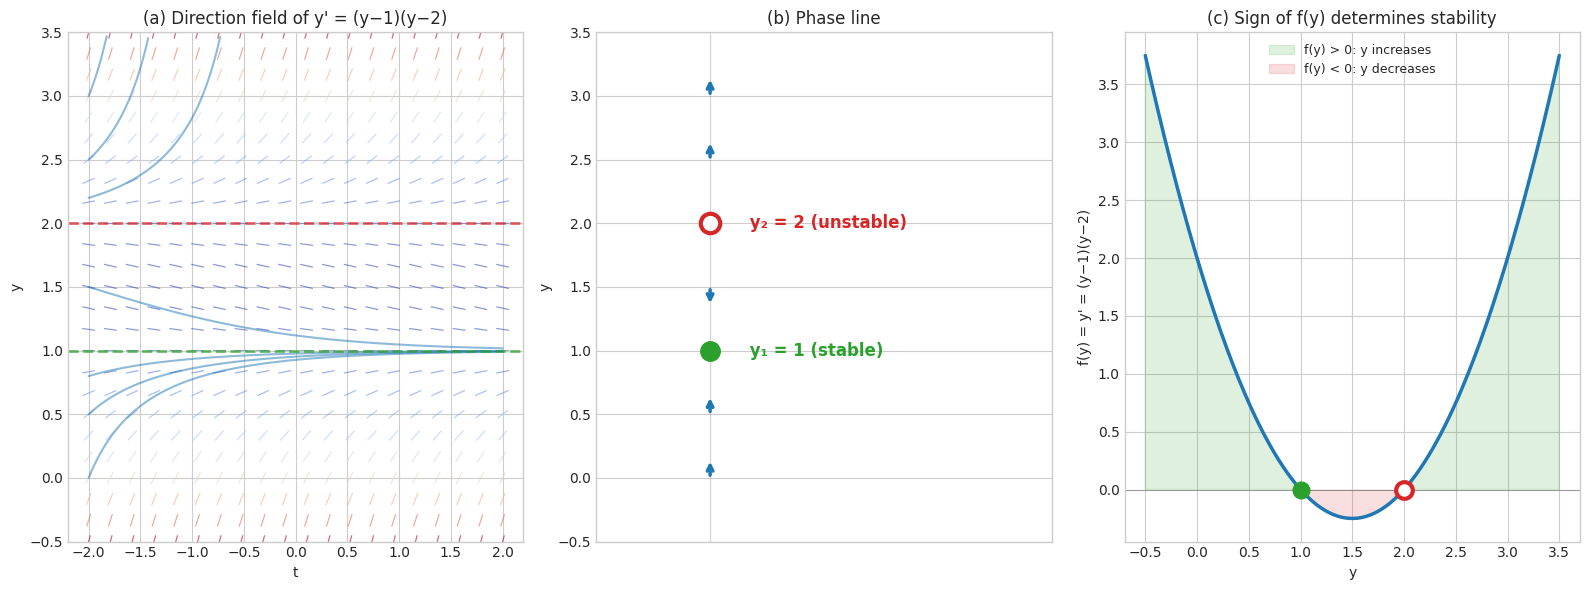

In [5]:
# Reproduce AEM Figure 22: Direction field, phase line, and f(y) parabola
# Using a different autonomous ODE: y' = (y - 1)(y - 2)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# (a) Direction field
ax = axes[0]
f_auto = lambda t, y: (y - 1) * (y - 2)
T, Y = np.meshgrid(np.linspace(-2, 2, 20), np.linspace(-0.5, 3.5, 25))
slopes = f_auto(T, Y)
U = np.ones_like(slopes)
V = slopes
N = np.sqrt(U**2 + V**2)
U, V = U / N, V / N
ax.quiver(T, Y, U, V, slopes, cmap='coolwarm', alpha=0.6,
          headwidth=0, headlength=0, headaxislength=0, pivot='middle', scale=35)

# Overlay solutions
t_fine = np.linspace(-2, 2, 300)
for y0 in [0.0, 0.5, 0.8, 1.5, 2.2, 2.5, 3.0, 3.5]:
    sol = solve_ivp(lambda t, y: [(y[0] - 1) * (y[0] - 2)],
                    [-2, 2], [y0], t_eval=t_fine, max_step=0.01)
    mask = (sol.y[0] > -0.5) & (sol.y[0] < 3.5)
    ax.plot(sol.t[mask], sol.y[0][mask], 'C0', alpha=0.5, lw=1.5)

ax.axhline(1, color='C2', ls='--', lw=2, alpha=0.7)
ax.axhline(2, color='C3', ls='--', lw=2, alpha=0.7)
ax.set_xlabel('t')
ax.set_ylabel('y')
ax.set_title("(a) Direction field of y' = (y−1)(y−2)")
ax.set_ylim(-0.5, 3.5)

# (b) Phase line
ax = axes[1]
y_line = np.linspace(-0.5, 3.5, 200)
fy = (y_line - 1) * (y_line - 2)

# Draw vertical line
ax.axvline(0, color='gray', lw=1, alpha=0.3)

# Arrows showing direction of motion
arrow_positions = [0.0, 0.5, 1.5, 2.5, 3.0]
for yp in arrow_positions:
    dy = (yp - 1) * (yp - 2)
    direction = 0.15 if dy > 0 else -0.15
    ax.annotate('', xy=(0, yp + direction), xytext=(0, yp),
                arrowprops=dict(arrowstyle='->', color='C0', lw=2.5))

# Equilibrium points
ax.plot(0, 1, 'o', color='C2', ms=14, zorder=5)
ax.plot(0, 2, 'o', color='C3', ms=14, zorder=5, markerfacecolor='white',
        markeredgecolor='C3', markeredgewidth=3)
ax.text(0.15, 1, ' y₁ = 1 (stable)', fontsize=12, va='center', color='C2', fontweight='bold')
ax.text(0.15, 2, ' y₂ = 2 (unstable)', fontsize=12, va='center', color='C3', fontweight='bold')
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 3.5)
ax.set_xlabel('')
ax.set_ylabel('y')
ax.set_title('(b) Phase line')
ax.set_xticks([])

# (c) f(y) parabola
ax = axes[2]
ax.plot(y_line, fy, 'C0', lw=2.5)
ax.axhline(0, color='gray', ls='-', lw=0.5)
ax.fill_between(y_line, fy, 0, where=fy > 0, alpha=0.15, color='C2', label="f(y) > 0: y increases")
ax.fill_between(y_line, fy, 0, where=fy < 0, alpha=0.15, color='C3', label="f(y) < 0: y decreases")
ax.plot(1, 0, 'o', color='C2', ms=12, zorder=5)
ax.plot(2, 0, 'o', color='C3', ms=12, zorder=5, markerfacecolor='white',
        markeredgecolor='C3', markeredgewidth=3)
ax.set_xlabel('y')
ax.set_ylabel("f(y) = y' = (y−1)(y−2)")
ax.set_title('(c) Sign of f(y) determines stability')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

The three panels show equivalent views of stability:

- **(a) Direction field**: solutions converge to $y_1 = 1$ (stable) and diverge from $y_2 = 2$ (unstable)
- **(b) Phase line**: condenses the direction field to a single vertical line with arrows — upward arrows where $f(y) > 0$, downward where $f(y) < 0$. Filled dot = stable, open dot = unstable
- **(c) Parabola $f(y)$**: at a zero of $f$, if $f$ crosses from positive to negative (as at $y_1 = 1$), solutions converge → **stable**. If from negative to positive (as at $y_2 = 2$) → **unstable**

**General rule:** An equilibrium $y^*$ is stable if $f'(y^*) < 0$ and unstable if $f'(y^*) > 0$.

## 6. Logistic Growth with Harvesting — The Schaefer Model

A powerful extension from AEM Problem Set 1.5 (Problem 36): what happens when we harvest from a logistic population at rate $H\,y$? This models continuous dilution in a **chemostat** — a bioreactor where fresh medium flows in and culture flows out at rate $H$.

$$y' = Ay - By^2 - Hy = (A - H)\,y - By^2$$

This is still a logistic equation with effective growth rate $(A - H)$ and new equilibria:

$$y_1 = 0, \qquad y_2 = \frac{A - H}{B}$$

When $H < A$: the population survives at a reduced carrying capacity $(A-H)/B$.
When $H \geq A$: the only equilibrium is extinction ($y = 0$).

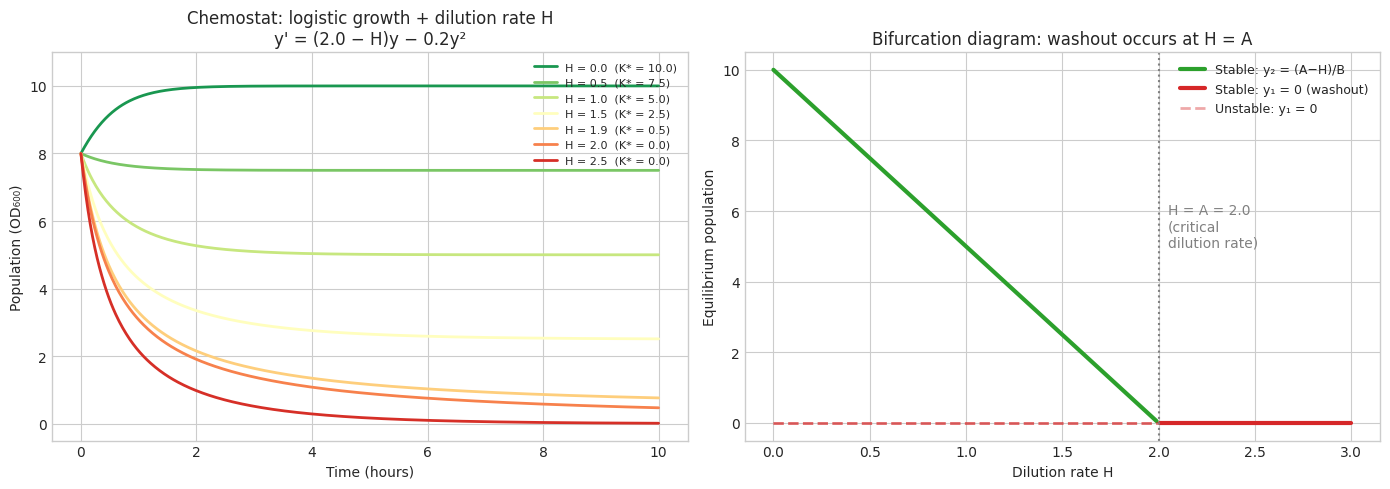

In [6]:
# Chemostat model: logistic growth with continuous dilution
A_ch = 2.0
B_ch = 0.2
y0_ch = 8.0  # initial culture density

t = np.linspace(0, 10, 500)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: time series for different dilution rates
ax = axes[0]
dilution_rates = [0.0, 0.5, 1.0, 1.5, 1.9, 2.0, 2.5]
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(dilution_rates)))

for H, col in zip(dilution_rates, colors):
    A_eff = A_ch - H
    if A_eff > 0:
        y = logistic_solution(t, y0_ch, A_eff, B_ch)
    elif A_eff == 0:
        # y' = -By² → y = y0/(1 + B·y0·t)
        y = y0_ch / (1 + B_ch * y0_ch * t)
    else:
        # y' = A_eff·y - By² with A_eff < 0 → decays to 0
        sol = solve_ivp(lambda t, y: [A_eff * y[0] - B_ch * y[0]**2],
                        [0, 10], [y0_ch], t_eval=t)
        y = sol.y[0]
    K_eff = max(A_eff / B_ch, 0) if A_eff > 0 else 0
    ax.plot(t, y, color=col, lw=2,
            label=f'H = {H:.1f}  (K* = {K_eff:.1f})')

ax.set_xlabel('Time (hours)')
ax.set_ylabel('Population (OD₆₀₀)')
ax.set_title(f'Chemostat: logistic growth + dilution rate H\n'
             f'y\' = ({A_ch} − H)y − {B_ch}y²')
ax.legend(fontsize=8)
ax.set_ylim(-0.5, 11)

# Right: bifurcation diagram — equilibrium vs H
ax = axes[1]
H_range = np.linspace(0, 3, 200)
K_eff = np.maximum((A_ch - H_range) / B_ch, 0)

# Stable equilibrium
ax.plot(H_range[H_range <= A_ch], K_eff[H_range <= A_ch],
        'C2', lw=3, label='Stable: y₂ = (A−H)/B')
# Zero equilibrium (stable when H ≥ A)
ax.plot(H_range, np.zeros_like(H_range), 'C3--', lw=2, alpha=0.5)
ax.plot(H_range[H_range >= A_ch], np.zeros(np.sum(H_range >= A_ch)),
        'C3', lw=3, label='Stable: y₁ = 0 (washout)')
# Zero equilibrium (unstable when H < A)
ax.plot(H_range[H_range < A_ch], np.zeros(np.sum(H_range < A_ch)),
        'C3--', lw=2, alpha=0.4, label='Unstable: y₁ = 0')

ax.axvline(A_ch, color='gray', ls=':', lw=1.5)
ax.text(A_ch + 0.05, 5, f'H = A = {A_ch}\n(critical\ndilution rate)',
        fontsize=10, color='gray')

ax.set_xlabel('Dilution rate H')
ax.set_ylabel('Equilibrium population')
ax.set_title('Bifurcation diagram: washout occurs at H = A')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

The **bifurcation diagram** (right) shows a critical transition at $H = A$:

- Below the critical dilution rate ($H < A$): the culture survives at reduced density $(A-H)/B$. The expression $Y = Hy_2 = H(A-H)/B$ gives the **sustainable yield** — the rate of biomass harvested in steady state.
- At and above $H = A$: **washout** — cells are removed faster than they can grow, and the population collapses to zero.

This is the fundamental tradeoff in continuous fermentation: higher dilution rates give faster throughput but risk washout.

## 7. Phase Line Analysis for the Logistic Equation

Let's apply the full phase-line analysis to our *E. coli* bioreactor model, showing how the sign of $f(y) = Ay(1 - y/K)$ determines the direction of motion along the $y$-axis.

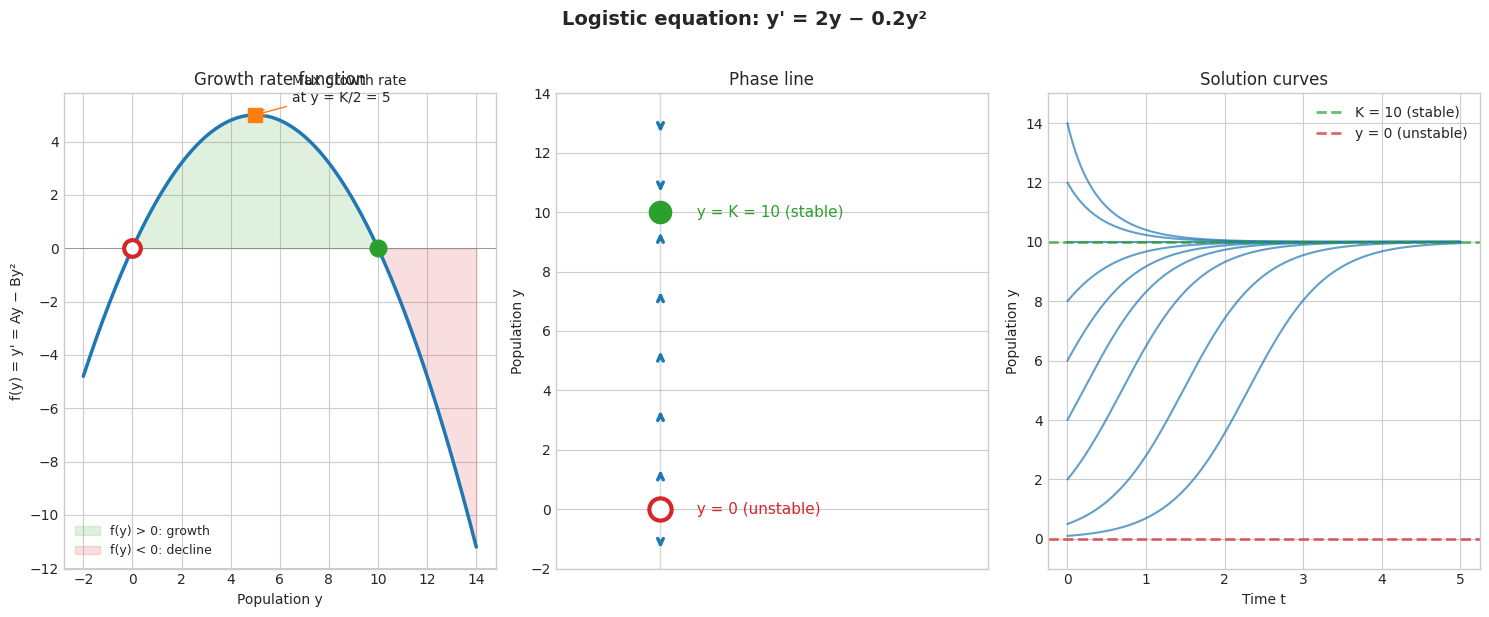

In [7]:
# Phase line analysis for the logistic equation
A_pl = 2.0
B_pl = 0.2
K_pl = A_pl / B_pl  # = 10

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# (a) f(y) = Ay - By² parabola
ax = axes[0]
y_vals = np.linspace(-2, 14, 300)
fy = A_pl * y_vals - B_pl * y_vals**2

ax.plot(y_vals, fy, 'C0', lw=2.5)
ax.axhline(0, color='gray', ls='-', lw=0.5)
ax.fill_between(y_vals, fy, 0, where=(fy > 0) & (y_vals > 0),
                alpha=0.15, color='C2', label="f(y) > 0: growth")
ax.fill_between(y_vals, fy, 0, where=(fy < 0) & (y_vals > 0),
                alpha=0.15, color='C3', label="f(y) < 0: decline")

ax.plot(0, 0, 'o', color='C3', ms=12, markerfacecolor='white',
        markeredgewidth=3, zorder=5)
ax.plot(K_pl, 0, 'o', color='C2', ms=12, zorder=5)

# Mark max growth rate at y = K/2
y_max = K_pl / 2
f_max = A_pl * y_max - B_pl * y_max**2
ax.plot(y_max, f_max, 's', color='C1', ms=10, zorder=5)
ax.annotate(f'Max growth rate\nat y = K/2 = {y_max:.0f}',
            xy=(y_max, f_max), xytext=(y_max + 1.5, f_max + 0.5),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='C1'))

ax.set_xlabel('Population y')
ax.set_ylabel("f(y) = y' = Ay − By²")
ax.set_title('Growth rate function')
ax.legend(fontsize=9)

# (b) Phase line
ax = axes[1]
ax.axvline(0, color='gray', lw=1, alpha=0.3)

# Arrows
for yp in [-1, 1, 3, 5, 7, 9, 11, 13]:
    dy = A_pl * yp - B_pl * yp**2
    if abs(dy) < 0.01:
        continue
    direction = 0.4 * np.sign(dy)
    ax.annotate('', xy=(0, yp + direction), xytext=(0, yp),
                arrowprops=dict(arrowstyle='->', color='C0', lw=2.5))

ax.plot(0, 0, 'o', color='C3', ms=16, markerfacecolor='white',
        markeredgewidth=3, zorder=5)
ax.plot(0, K_pl, 'o', color='C2', ms=16, zorder=5)
ax.text(0.2, 0, f'  y = 0 (unstable)', fontsize=11, va='center', color='C3')
ax.text(0.2, K_pl, f'  y = K = {K_pl:.0f} (stable)', fontsize=11, va='center', color='C2')

ax.set_xlim(-0.8, 2.5)
ax.set_ylim(-2, 14)
ax.set_ylabel('Population y')
ax.set_title('Phase line')
ax.set_xticks([])

# (c) Solution curves
ax = axes[2]
t = np.linspace(0, 5, 300)
y0_list = [0.1, 0.5, 2, 4, 6, 8, 10, 12, 14]
for y0 in y0_list:
    y = logistic_solution(t, y0, A_pl, B_pl)
    ax.plot(t, y, 'C0', lw=1.5, alpha=0.7)

ax.axhline(K_pl, color='C2', ls='--', lw=2, alpha=0.7, label=f'K = {K_pl:.0f} (stable)')
ax.axhline(0, color='C3', ls='--', lw=2, alpha=0.7, label='y = 0 (unstable)')
ax.set_xlabel('Time t')
ax.set_ylabel('Population y')
ax.set_title('Solution curves')
ax.legend()
ax.set_ylim(-1, 15)

plt.suptitle('Logistic equation: y\' = 2y − 0.2y²', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Notable feature: the **maximum growth rate** occurs at $y = K/2$ (the vertex of the parabola $f(y)$). This is the inflection point of the sigmoidal growth curve — the moment when growth begins to slow. In bioreactor practice, this corresponds to the transition from exponential to deceleration phase and is often used to time nutrient feeding strategies.

## 8. Fitting the Logistic Model to Simulated Bioreactor Data

Let's generate realistic *E. coli* growth data with noise and fit the logistic model, demonstrating how the mathematics connects to experimental practice.

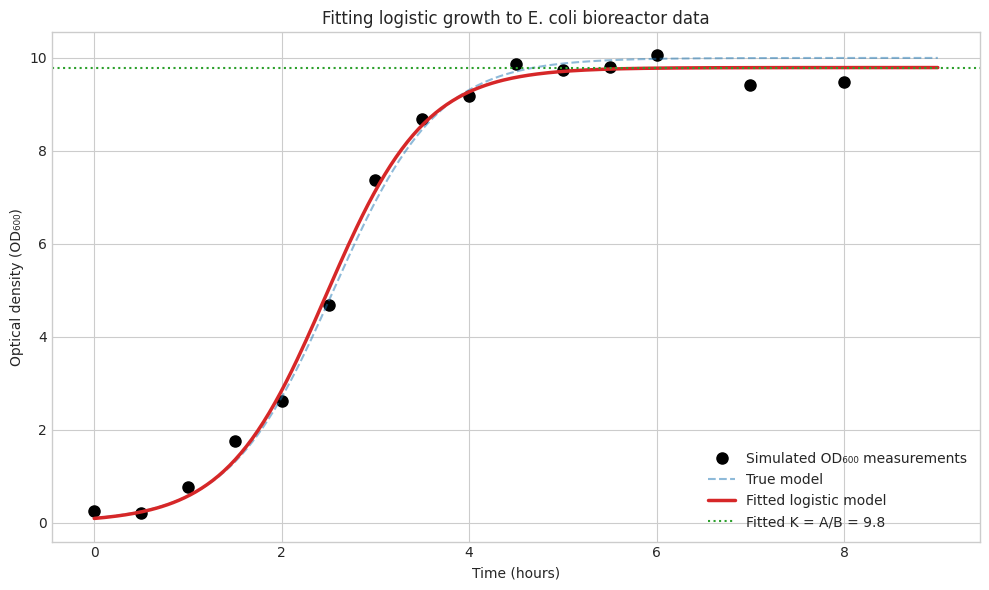

Fitted parameters:
  A (growth rate)      = 1.884 ± 0.120  (true: 1.8)
  B (braking coeff)    = 0.192 ± 0.013  (true: 0.18)
  y₀ (initial OD)     = 0.092 ± 0.027  (true: 0.1)
  K = A/B (capacity)   = 9.79         (true: 10.0)


In [8]:
from scipy.optimize import curve_fit

# Generate realistic noisy data
np.random.seed(42)
A_true = 1.8
B_true = 0.18
K_true = A_true / B_true  # = 10
y0_true = 0.1

t_data = np.array([0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6, 7, 8])
y_clean = logistic_solution(t_data, y0_true, A_true, B_true)
y_data = y_clean + np.random.normal(0, 0.3, len(t_data))
y_data = np.maximum(y_data, 0.01)  # OD can't be negative

# Fit logistic model
def logistic_fit(t, A, B, y0):
    K = A / B
    return K / (1 + (K / y0 - 1) * np.exp(-A * t))

popt, pcov = curve_fit(logistic_fit, t_data, y_data, p0=[1.5, 0.15, 0.1],
                       bounds=([0, 0, 0], [10, 5, 5]))
A_fit, B_fit, y0_fit = popt
perr = np.sqrt(np.diag(pcov))

# Plot
t_fine = np.linspace(0, 9, 300)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(t_data, y_data, 'ko', ms=8, label='Simulated OD₆₀₀ measurements')
ax.plot(t_fine, logistic_solution(t_fine, y0_true, A_true, B_true),
        'C0--', lw=1.5, alpha=0.5, label='True model')
ax.plot(t_fine, logistic_fit(t_fine, *popt),
        'C3', lw=2.5, label='Fitted logistic model')
ax.axhline(A_fit / B_fit, color='C2', ls=':', lw=1.5,
           label=f'Fitted K = A/B = {A_fit/B_fit:.1f}')

ax.set_xlabel('Time (hours)')
ax.set_ylabel('Optical density (OD₆₀₀)')
ax.set_title('Fitting logistic growth to E. coli bioreactor data')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("Fitted parameters:")
print(f"  A (growth rate)      = {A_fit:.3f} ± {perr[0]:.3f}  (true: {A_true})")
print(f"  B (braking coeff)    = {B_fit:.3f} ± {perr[1]:.3f}  (true: {B_true})")
print(f"  y₀ (initial OD)     = {y0_fit:.3f} ± {perr[2]:.3f}  (true: {y0_true})")
print(f"  K = A/B (capacity)   = {A_fit/B_fit:.2f}         (true: {K_true:.1f})")